# Chapter 35: Fitting Is Not Confirming

*Systems Thinking with AI* by Jason Karpeles

A fit is the answer to a search, and the holdout and the choice of knob decide what it is worth.

**Goal.** Four small experiments on the chapter's tank. Score a cycle two ways and see a flat line beat a correct model, count what a fit costs and when it is refused, run the grid search and read its residual, and move the wrong knob to see the holdout catch it.

**Demonstrations**

1. Scoring a cycle by point-by-point distance
2. How many knobs the record allows, and what they cost
3. The tank, fitted by a grid
4. The wrong knob passes the window and fails the holdout

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/35-calibration/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/35-calibration/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_13_expressions/code/expressions.py`

In [2]:
%%module chapters.chapter_13_expressions.code.expressions
"""Evaluate a model's algebra without granting it the power to run arbitrary code.

A declarative model spec carries expressions as text. Handing that text to eval()
gives whoever wrote the spec the ability to do anything the process can do. This
module parses to a syntax tree, walks it against a whitelist, and refuses anything
outside it.
"""

import ast
import math
from collections.abc import Callable

ALLOWED_FUNCTIONS: dict[str, Callable[..., float]] = {
    "min": min,
    "max": max,
    "abs": abs,
    "exp": math.exp,
    "log": math.log,
    "sqrt": math.sqrt,
}

_ALLOWED_NODES = (
    ast.Expression, ast.BinOp, ast.UnaryOp, ast.Name, ast.Load, ast.Constant, ast.Call,
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Pow, ast.USub, ast.UAdd, ast.Mod,
    ast.Compare, ast.Lt, ast.LtE, ast.Gt, ast.GtE, ast.Eq, ast.NotEq, ast.IfExp,
)


class UnsafeExpression(ValueError):
    """Raised when an expression asks for something the whitelist does not permit."""


def parse(text: str, functions: dict[str, Callable[..., float]] | None = None) -> ast.Expression:
    """Parse an expression and reject every construct outside the whitelist.

    `functions` names what may be called. It defaults to this module's own table,
    and Chapter 23 passes its approved registry in instead, so a model calls what
    a person approved rather than what this file happens to import.
    """
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    if not text.strip():
        raise UnsafeExpression("an expression cannot be empty")
    try:
        tree = ast.parse(text, mode="eval")
    except SyntaxError as exc:
        raise UnsafeExpression(f"not a valid expression: {exc.msg}") from exc
    for node in ast.walk(tree):
        if not isinstance(node, _ALLOWED_NODES):
            raise UnsafeExpression(f"{type(node).__name__} is not permitted in a model expression")
        if isinstance(node, ast.Call):
            if not isinstance(node.func, ast.Name):
                raise UnsafeExpression("only direct calls to whitelisted functions are permitted")
            if node.func.id not in allowed:
                raise UnsafeExpression(f"'{node.func.id}' is not an allowed function")
            if node.keywords:
                raise UnsafeExpression("keyword arguments are not permitted")
        if isinstance(node, ast.Constant) and not isinstance(node.value, (int, float, bool)):
            raise UnsafeExpression("only numeric constants are permitted")
    return tree


def variables(text: str, functions: dict[str, Callable[..., float]] | None = None) -> set[str]:
    """Every name an expression reads. The model's dependency edges come from here."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    return {n.id for n in ast.walk(tree) if isinstance(n, ast.Name) and n.id not in allowed}


def evaluate(text: str, values: dict[str, float],
             functions: dict[str, Callable[..., float]] | None = None) -> float:
    """Evaluate a whitelisted expression against a supplied set of named values."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    needed = variables(text, allowed)
    missing = needed - set(values)
    if missing:
        raise ValueError(f"no value supplied for: {sorted(missing)}")
    scope: dict[str, object] = {**allowed, **values}
    return eval(compile(tree, "<model>", "eval"), {"__builtins__": {}}, scope)  # noqa: S307


`chapters/chapter_20_model_document/code/document.py`

In [3]:
%%module chapters.chapter_20_model_document.code.document
"""A model as structured data: validated, versioned, and hashable.

An imperative model is a program. A change to it is a diff of code, and whether
the change altered the model's meaning requires reading the code. A declarative
model is a document, and a change to it is a diff of assumptions.
"""

import hashlib
import json
import re
from dataclasses import MISSING, asdict, dataclass, field, fields

from chapters.chapter_13_expressions.code.expressions import UnsafeExpression, variables

ID_PATTERN = re.compile(r"^[a-z][a-z0-9_]*$")
KINDS = ("stock", "flow", "auxiliary", "parameter", "perception", "lookup", "delay")


@dataclass(frozen=True)
class Variable:
    """One named quantity, with everything needed to place it in the model."""

    id: str
    kind: str
    unit: str
    equation: str = ""
    value: float | None = None
    evidence: str = "assumed"
    note: str = ""
    target: str = ""   # for a flow: which stock it moves
    sign: int = 1      # +1 adds to the target, -1 removes from it
    points: tuple[tuple[float, float], ...] = ()   # for a lookup: the observed shape
    delay_time: float | None = None                # for a delay: its mean, in horizon units

    def __post_init__(self) -> None:
        if not ID_PATTERN.match(self.id):
            raise ValueError(f"'{self.id}' is not a canonical id: lower case, digits, underscores")
        if self.kind not in KINDS:
            raise ValueError(f"kind must be one of {KINDS}")
        if not self.unit.strip():
            raise ValueError(f"'{self.id}' has no unit")
        if self.kind in ("stock", "parameter") and self.value is None:
            raise ValueError(f"'{self.id}' is a {self.kind} and needs a value")
        if self.kind in ("flow", "auxiliary") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation")
        if self.sign not in (1, -1):
            raise ValueError("sign must be +1 or -1")
        if self.target and self.kind != "flow":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot target a stock")
        if self.kind in ("lookup", "delay") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation for its input")
        if self.points and self.kind != "lookup":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry lookup points")
        if self.kind == "lookup":
            if len(self.points) < 2:
                raise ValueError(f"lookup '{self.id}' needs at least two points")
            xs = [x for x, _ in self.points]
            if xs != sorted(xs) or len(set(xs)) != len(xs):
                raise ValueError(f"lookup '{self.id}' needs points with increasing x")
        if self.delay_time is not None and self.kind != "delay":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry a delay time")
        if self.kind == "delay" and (self.delay_time is None or self.delay_time <= 0):
            raise ValueError(f"delay '{self.id}' needs a positive delay_time")


@dataclass
class ModelDocument:
    """The whole model, as data. Nothing here executes."""

    name: str
    version: str
    variables: list[Variable] = field(default_factory=list)
    horizon: int = 1
    horizon_unit: str = "week"
    time_step: float = 1.0

    def __post_init__(self) -> None:
        if not re.match(r"^\d+\.\d+\.\d+$", self.version):
            raise ValueError("version must be semantic: major.minor.patch")
        ids = [v.id for v in self.variables]
        duplicates = {i for i in ids if ids.count(i) > 1}
        if duplicates:
            raise ValueError(f"duplicate ids: {sorted(duplicates)}")
        if self.time_step <= 0 or self.horizon < 1:
            raise ValueError("time_step must be positive and horizon at least 1")

    def by_id(self, name: str) -> Variable:
        for v in self.variables:
            if v.id == name:
                return v
        raise KeyError(f"no variable '{name}' in this model")

    @staticmethod
    def _asserted(variable: "Variable") -> dict:
        """A variable's fields minus the ones sitting at their default.

        A field at its default asserts nothing, so it stays out of the canonical
        form. That is what lets the schema gain a field without changing the hash
        of every document written before it existed.
        """
        defaults = {
            f.name: (f.default if f.default is not MISSING else None) for f in fields(variable)
        }
        return {k: v for k, v in asdict(variable).items() if v != defaults.get(k)}

    def canonical(self) -> str:
        """A stable text form: keys sorted, variables ordered, no incidental whitespace."""
        payload = {
            "name": self.name,
            "horizon": self.horizon,
            "horizon_unit": self.horizon_unit,
            "time_step": self.time_step,
            "variables": sorted(
                (self._asserted(v) for v in self.variables), key=lambda d: d["id"]
            ),
        }
        return json.dumps(payload, sort_keys=True, separators=(",", ":"))

    def hash(self) -> str:
        """Content hash of the model's meaning. Excludes the version deliberately."""
        return hashlib.sha256(self.canonical().encode()).hexdigest()[:16]


def validate(document: ModelDocument) -> list[str]:
    """Every problem findable without running anything."""
    problems = []
    known = {v.id for v in document.variables}
    for variable in document.variables:
        if variable.kind == "parameter" and variable.evidence == "observed" and not variable.note:
            problems.append(f"'{variable.id}' claims observation with no source note")
        if variable.equation:
            try:
                referenced = variables(variable.equation)
            except UnsafeExpression as exc:
                problems.append(f"'{variable.id}' has an invalid expression: {exc}")
            else:
                for name in sorted(referenced - known):
                    problems.append(f"'{variable.id}' references undefined '{name}'")
    stocks = {v.id for v in document.variables if v.kind == "stock"}
    for variable in document.variables:
        if variable.kind == "flow":
            if not variable.target:
                problems.append(f"flow '{variable.id}' does not say which stock it moves")
            elif variable.target not in stocks:
                problems.append(f"flow '{variable.id}' targets '{variable.target}', not a stock")
    for stock in sorted(stocks):
        moved = [v for v in document.variables if v.kind == "flow" and v.target == stock]
        if not moved:
            problems.append(f"stock '{stock}' has no flow: nothing can change it")
    if not stocks and not any(v.kind == "delay" for v in document.variables):
        problems.append("no stock or delay: nothing in this model carries state")
    return problems


def diff(old: ModelDocument, new: ModelDocument) -> dict[str, object]:
    """What changed between two versions, in the model's own terms."""
    old_ids = {v.id: v for v in old.variables}
    new_ids = {v.id: v for v in new.variables}
    changed = [
        i for i in old_ids.keys() & new_ids.keys() if asdict(old_ids[i]) != asdict(new_ids[i])
    ]
    return {
        "added": sorted(new_ids.keys() - old_ids.keys()),
        "removed": sorted(old_ids.keys() - new_ids.keys()),
        "changed": sorted(changed),
        "fields": {
            f.name: {"before": getattr(old, f.name), "after": getattr(new, f.name)}
            for f in fields(old)
            if f.name != "variables" and getattr(old, f.name) != getattr(new, f.name)
        },
        "variables": {
            name: {"before": asdict(old_ids[name]) if name in old_ids else None,
                   "after": asdict(new_ids[name]) if name in new_ids else None}
            for name in sorted(set(changed) | (old_ids.keys() ^ new_ids.keys()))
        },
    }


`chapters/chapter_15_lookups/code/lookup.py`

In [4]:
%%module chapters.chapter_15_lookups.code.lookup
"""A lookup that interpolates inside its evidence and refuses outside it."""

from bisect import bisect_left


class OutsideDomain(ValueError):
    """Raised when a lookup is asked about a region no observation covers."""


class Lookup:
    """Piecewise-linear interpolation over observed points, with a closed domain."""

    def __init__(self, points: list[tuple[float, float]], name: str = "lookup") -> None:
        if len(points) < 2:
            raise ValueError("a lookup needs at least two observed points")
        ordered = sorted(points)
        xs = [x for x, _ in ordered]
        if len(set(xs)) != len(xs):
            raise ValueError("a lookup cannot hold two values for the same input")
        self.name = name
        self.xs = xs
        self.ys = [y for _, y in ordered]

    @property
    def domain(self) -> tuple[float, float]:
        return self.xs[0], self.xs[-1]

    def __call__(self, x: float) -> float:
        low, high = self.domain
        # A solver that lands on a domain end arrives a few machine epsilons past
        # it. Refusing that is refusing arithmetic, not refusing extrapolation, so
        # an input within a hair of an end is snapped to it and anything further
        # out is still refused.
        tolerance = 1e-9 * max(1.0, abs(low), abs(high))
        if low - tolerance <= x < low:
            x = low
        elif high < x <= high + tolerance:
            x = high
        if not low <= x <= high:
            raise OutsideDomain(
                f"{self.name} was asked about {x}, outside its observed domain [{low}, {high}]"
            )
        i = bisect_left(self.xs, x)
        if self.xs[i] == x:
            return self.ys[i]
        x0, x1, y0, y1 = self.xs[i - 1], self.xs[i], self.ys[i - 1], self.ys[i]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

    def is_monotonic(self) -> bool:
        """True when the relationship never reverses direction."""
        up = all(b >= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        down = all(b <= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        return up or down

    def is_bounded_by(self, low: float, high: float) -> bool:
        return all(low <= y <= high for y in self.ys)


def fit_polynomial(points: list[tuple[float, float]], degree: int) -> list[float]:
    """Least-squares polynomial coefficients, lowest order first. Deliberately naive."""
    n = degree + 1
    if len(points) < n:
        raise ValueError("not enough points for that degree")
    xs = [x for x, _ in points]
    ys = [y for _, y in points]
    a = [[sum(x ** (i + j) for x in xs) for j in range(n)] for i in range(n)]
    b = [sum(y * x**i for x, y in zip(xs, ys, strict=True)) for i in range(n)]
    for col in range(n):
        pivot = max(range(col, n), key=lambda r: abs(a[r][col]))
        if abs(a[pivot][col]) < 1e-12:
            raise ValueError("the fit is singular at this degree")
        a[col], a[pivot] = a[pivot], a[col]
        b[col], b[pivot] = b[pivot], b[col]
        for r in range(n):
            if r == col:
                continue
            factor = a[r][col] / a[col][col]
            a[r] = [x - factor * y for x, y in zip(a[r], a[col], strict=True)]
            b[r] -= factor * b[col]
    return [b[i] / a[i][i] for i in range(n)]


def evaluate_polynomial(coefficients: list[float], x: float) -> float:
    """A fit will answer any question asked of it. That is the problem."""
    return sum(c * x**i for i, c in enumerate(coefficients))


`chapters/chapter_08_causal_graph/code/graph.py`

In [5]:
%%module chapters.chapter_08_causal_graph.code.graph
"""A causal graph whose links carry evidence status and time semantics.

A link with no evidence status and no delay is a drawing. This module refuses to
treat one as a finding.
"""

from dataclasses import dataclass

EVIDENCE_LEVELS = ("observed", "inferred", "assumed", "proposed")


@dataclass(frozen=True)
class Link:
    """One causal claim: source, target, sign, how it is known, and whether it is delayed."""

    source: str
    target: str
    polarity: int  # +1 same direction, -1 opposite direction
    evidence: str
    delayed: bool | None = None  # None means nobody recorded the time semantics
    note: str = ""

    def __post_init__(self) -> None:
        if self.polarity not in (1, -1):
            raise ValueError("polarity must be +1 or -1")
        if self.evidence not in EVIDENCE_LEVELS:
            raise ValueError(f"evidence must be one of {EVIDENCE_LEVELS}")
        if self.source == self.target:
            raise ValueError("a link must join two different variables")


def simple_cycles(outgoing: dict[str, list[str]] | dict[str, set[str]]) -> list[list[str]]:
    """Every simple cycle in a directed graph, each reported once from its lowest node.

    Kept separate from the link list so the same enumeration can run on a graph
    derived from equations, which is what Chapter 21's compiler does with it.
    """
    loops: list[list[str]] = []
    seen: set[tuple[str, ...]] = set()

    def walk(start: str, node: str, path: list[str]) -> None:
        for nxt in sorted(outgoing.get(node, [])):
            if nxt == start:
                rotation = tuple(path)
                if min(path) == path[0] and rotation not in seen:
                    seen.add(rotation)
                    loops.append(list(path))
            elif nxt not in path:
                walk(start, nxt, path + [nxt])

    for node in sorted(outgoing):
        walk(node, node, [node])
    return loops


def find_loops(links: list[Link]) -> list[list[str]]:
    """Enumerate every simple feedback loop, each reported once from its lowest node."""
    outgoing: dict[str, list[str]] = {}
    for link in links:
        outgoing.setdefault(link.source, []).append(link.target)
    return simple_cycles(outgoing)


def loop_polarity(loop: list[str], links: list[Link]) -> str:
    """Reinforcing when the loop holds an even number of negative links, balancing otherwise."""
    index = {(link.source, link.target): link.polarity for link in links}
    negatives = 0
    for i, node in enumerate(loop):
        nxt = loop[(i + 1) % len(loop)]
        polarity = index.get((node, nxt))
        if polarity is None:
            raise ValueError(f"no link from {node} to {nxt}")
        if polarity < 0:
            negatives += 1
    return "reinforcing" if negatives % 2 == 0 else "balancing"


def unsupported_links(links: list[Link]) -> list[Link]:
    """Links resting on assumption or proposal rather than observation or inference."""
    return [link for link in links if link.evidence in ("assumed", "proposed")]


def links_without_time_semantics(links: list[Link]) -> list[Link]:
    """Links where nobody recorded whether the effect is immediate or delayed."""
    return [link for link in links if link.delayed is None]


def audit(links: list[Link]) -> dict[str, int]:
    """Summarize what the diagram is resting on."""
    loops = find_loops(links)
    return {
        "links": len(links),
        "loops": len(loops),
        "reinforcing": sum(1 for loop in loops if loop_polarity(loop, links) == "reinforcing"),
        "balancing": sum(1 for loop in loops if loop_polarity(loop, links) == "balancing"),
        "unsupported": len(unsupported_links(links)),
        "no_time_semantics": len(links_without_time_semantics(links)),
    }


`chapters/chapter_21_compiler/code/compiler.py`

In [6]:
%%module chapters.chapter_21_compiler.code.compiler
"""Turn a model document into an evaluation order, or say precisely why it cannot.

Two kinds of cycle exist in a model and they need opposite treatment. A cycle
through a stock is feedback: legitimate, and resolved by the time step. A cycle
through auxiliaries alone is an algebraic loop. It may have a mathematical solution,
but this compiler has no simultaneous-equation solver and must refuse it.
"""

from chapters.chapter_08_causal_graph.code.graph import simple_cycles
from chapters.chapter_13_expressions.code.expressions import variables
from chapters.chapter_20_model_document.code.document import ModelDocument

# A delay carries its own level between steps, so a cycle through one closes over
# a time step exactly as a cycle through a stock does.
STATEFUL = ("stock", "delay")


def edges(document: ModelDocument) -> dict[str, set[str]]:
    """What each variable reads, derived from its equation rather than declared."""
    graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    known = set(graph)
    for variable in document.variables:
        if variable.equation:
            graph[variable.id] = {n for n in variables(variable.equation) if n in known}
    return graph


def declared_versus_inferred(
    document: ModelDocument, declared: dict[str, set[str]]
) -> dict[str, set[str]]:
    """Edges someone wrote down that the equations do not support, and the reverse."""
    inferred = edges(document)
    out: dict[str, set[str]] = {}
    # Sorted so the report reads the same way twice. Set order is not stable across runs.
    for node in sorted(set(inferred) | set(declared)):
        missing = declared.get(node, set()) - inferred.get(node, set())
        extra = inferred.get(node, set()) - declared.get(node, set())
        if missing or extra:
            out[node] = missing | extra
    return out


def strongly_connected(graph: dict[str, set[str]]) -> list[list[str]]:
    """Tarjan's algorithm. Every group of nodes that can all reach each other."""
    index: dict[str, int] = {}
    low: dict[str, int] = {}
    stack: list[str] = []
    on_stack: set[str] = set()
    result: list[list[str]] = []
    counter = 0

    def walk(node: str) -> None:
        nonlocal counter
        index[node] = low[node] = counter
        counter += 1
        stack.append(node)
        on_stack.add(node)
        for nxt in sorted(graph.get(node, ())):
            if nxt not in index:
                walk(nxt)
                low[node] = min(low[node], low[nxt])
            elif nxt in on_stack:
                low[node] = min(low[node], index[nxt])
        if low[node] == index[node]:
            group = []
            while True:
                member = stack.pop()
                on_stack.discard(member)
                group.append(member)
                if member == node:
                    break
            result.append(sorted(group))

    for node in sorted(graph):
        if node not in index:
            walk(node)
    return result


def algebraic_loops(document: ModelDocument) -> list[list[str]]:
    """Cycles with no stateful node, unsupported by this explicit runtime."""
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {k: {x for x in v if x not in stateful} for k, v in edges(document).items()}
    graph = {k: v for k, v in graph.items() if k not in stateful}
    return [
        group
        for group in strongly_connected(graph)
        if len(group) > 1 or any(group[0] in graph.get(group[0], set()) for _ in (0,))
    ]


def influence(document: ModelDocument) -> dict[str, set[str]]:
    """The graph the other way round: what each variable affects, not what it reads.

    `edges` answers the compiler's question, which is what a variable depends on.
    A loop is a path of influence, so enumerating loops needs the arrows reversed.
    """
    reversed_graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    for name, reads in edges(document).items():
        for source in reads:
            reversed_graph[source].add(name)
    # A flow reaches its stock through the target field rather than an equation,
    # so that arrow is absent from `edges` and is exactly where a loop closes.
    for variable in document.variables:
        if variable.kind == "flow" and variable.target:
            reversed_graph[variable.id].add(variable.target)
    return reversed_graph


def feedback_loops(document: ModelDocument) -> list[list[str]]:
    """Every feedback loop in the model, enumerated from the equations.

    Chapter 8 enumerates loops in a graph somebody drew. This runs the same
    enumeration over the graph the equations imply, and keeps only the loops that
    pass through something stateful, because those are the ones that close over a
    time step. A cycle with no state in it is an algebraic loop, which
    `algebraic_loops` reports as a defect instead.
    """
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    return [
        loop for loop in simple_cycles(influence(document))
        if any(node in stateful for node in loop)
    ]


def evaluation_order(document: ModelDocument) -> list[str]:
    """Topological order for everything computed within a step.

    Stocks are excluded: their values are state carried in from the previous step,
    so nothing inside a step has to compute them.
    """
    loops = algebraic_loops(document)
    if loops:
        raise ValueError(f"cannot order a model with algebraic loops: {loops}")
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {
        k: {x for x in v if x not in stateful}
        for k, v in edges(document).items()
        if k not in stateful
    }
    order: list[str] = []
    seen: set[str] = set()

    def visit(node: str) -> None:
        if node in seen:
            return
        seen.add(node)
        for dependency in sorted(graph.get(node, ())):
            visit(dependency)
        order.append(node)

    for node in sorted(graph):
        visit(node)
    return order


def diagnostics(document: ModelDocument) -> list[str]:
    """Compiler output written to teach rather than to scold."""
    messages = []
    for loop in algebraic_loops(document):
        members = ", ".join(loop)
        messages.append(
            f"algebraic component: {{{members}}}. These depend on each other within one step. "
            f"This compiler has no simultaneous-equation solver. Rewrite the equations to remove "
            f"the cycle, or route a link through a stock if the model requires a delay."
        )
    graph = edges(document)
    for node, reads in sorted(graph.items()):
        if node in reads:
            messages.append(f"'{node}' reads itself. A stock does this through time, not algebra.")
    return messages


`chapters/chapter_22_runtime/code/runtime.py`

In [7]:
%%module chapters.chapter_22_runtime.code.runtime
"""What 'run' means: evaluate in order, advance the stocks, record, repeat.

Everything this needs was built in earlier chapters. The document says what exists
(Chapter 20), the compiler says what order to evaluate it in (Chapter 21), the
evaluator computes each expression safely (Chapter 13), and the solver advances the
stocks (Chapter 19). This module is the composition and nothing more.
"""

import random
from dataclasses import dataclass, field

from chapters.chapter_13_expressions.code.expressions import evaluate
from chapters.chapter_15_lookups.code.lookup import Lookup
from chapters.chapter_20_model_document.code.document import ModelDocument, validate
from chapters.chapter_21_compiler.code.compiler import evaluation_order


@dataclass
class RunSettings:
    """The semantics of a run.

    The document supplies the default time step and horizon. Explicit run
    settings override those defaults and travel with the result. Reproduction
    requires the model document, the effective run settings, and the
    implementation version together as a reproduction bundle.
    """

    solver: str = "euler"
    dt: float = 1.0
    horizon: float = 20.0
    seed: int = 0

    def __post_init__(self) -> None:
        if self.solver not in ("euler", "rk4"):
            raise ValueError("solver must be 'euler' or 'rk4'")
        if self.dt <= 0 or self.horizon <= 0:
            raise ValueError("dt and horizon must be positive")


@dataclass
class Result:
    """Everything needed to reproduce and to audit a run."""

    model_hash: str
    settings: RunSettings
    times: list[float] = field(default_factory=list)
    series: dict[str, list[float]] = field(default_factory=dict)

    def final(self, name: str) -> float:
        return self.series[name][-1]


class Runtime:
    """Runs one model document."""

    def __init__(self, document: ModelDocument, settings: RunSettings | None = None) -> None:
        problems = validate(document)
        if problems:
            raise ValueError(f"model does not validate: {problems}")
        self.document = document
        # The document's own time step and horizon are the defaults, because a
        # semantic choice recorded in the document and then ignored by the runtime
        # is decoration. Explicit settings still win: a run may say otherwise, and
        # then it has said so on the record.
        self.settings = settings or RunSettings(
            dt=document.time_step, horizon=float(document.horizon)
        )
        self.order = evaluation_order(document)
        self.stocks = {v.id: float(v.value) for v in document.variables if v.kind == "stock"}
        self.lookups = {
            v.id: Lookup([tuple(p) for p in v.points], name=v.id)
            for v in document.variables if v.kind == "lookup"
        }
        # A first-order delay is a level that fills from its input and drains at
        # level / delay_time. Holding it as state lets the ordinary solver advance
        # it, so no separate stepping machinery is needed.
        self.delays = {v.id: v for v in document.variables if v.kind == "delay"}
        for name, variable in self.delays.items():
            initial_rate = float(variable.value or 0.0)
            self.stocks[self._level(name)] = initial_rate * float(variable.delay_time)
        self.rng = random.Random(self.settings.seed)

    @staticmethod
    def _level(name: str) -> str:
        """State key for a delay's hidden level. Named so a series is readable."""
        return f"{name}__level"

    def _environment(self, state: dict[str, float]) -> dict[str, float]:
        """Evaluate every computed quantity in dependency order from the given state."""
        env: dict[str, float] = dict(state)
        for name, variable in self.delays.items():
            env[name] = state[self._level(name)] / float(variable.delay_time)
        for name in self.order:
            variable = self.document.by_id(name)
            if variable.kind in ("parameter",):
                env[name] = float(variable.value)
            elif variable.kind == "lookup":
                env[name] = self.lookups[name](evaluate(variable.equation, env))
            elif variable.equation:
                env[name] = evaluate(variable.equation, env)
        return env

    def derivatives(self, state: dict[str, float]) -> dict[str, float]:
        """Net rate of change for every stock, from the flows attached to it."""
        env = self._environment(state)
        rates = dict.fromkeys(self.stocks, 0.0)
        for name, variable in self.delays.items():
            rates[self._level(name)] = evaluate(variable.equation, env) - env[name]
        for variable in self.document.variables:
            if variable.kind == "flow" and variable.target:
                rates[variable.target] += variable.sign * env[variable.id]
        return rates

    def _advance(self, state: dict[str, float], dt: float) -> dict[str, float]:
        if self.settings.solver == "euler":
            rates = self.derivatives(state)
            return {k: v + dt * rates[k] for k, v in state.items()}
        k1 = self.derivatives(state)
        s2 = {k: v + dt / 2 * k1[k] for k, v in state.items()}
        k2 = self.derivatives(s2)
        s3 = {k: v + dt / 2 * k2[k] for k, v in state.items()}
        k3 = self.derivatives(s3)
        s4 = {k: v + dt * k3[k] for k, v in state.items()}
        k4 = self.derivatives(s4)
        return {
            k: v + dt * (k1[k] + 2 * k2[k] + 2 * k3[k] + k4[k]) / 6 for k, v in state.items()
        }

    def run(self) -> Result:
        """Advance to the horizon, recording every stock and every computed quantity."""
        dt, horizon = self.settings.dt, self.settings.horizon
        result = Result(model_hash=self.document.hash(), settings=self.settings)
        state = dict(self.stocks)
        t = 0.0
        while True:
            env = self._step(self._environment, state, t)
            result.times.append(t)
            for name, value in env.items():
                result.series.setdefault(name, []).append(value)
            if t >= horizon - 1e-12:
                break
            state = self._step(self._advance, state, t, dt)
            t += dt
        return result

    @staticmethod
    def _step(work, state, t, *args):
        """Run one piece of a step, and say when it failed if it does.

        A trajectory-dependent failure cannot be caught before the run, so the
        least a runtime owes is the time it happened at.
        """
        try:
            return work(state, *args)
        except (ArithmeticError, ValueError, KeyError) as exc:
            raise RuntimeError(f"run failed at time {t:g}: {exc}") from exc

    def checkpoint(self) -> dict[str, float]:
        """The whole of the model's state. Everything else is recomputed from it."""
        return dict(self.stocks)

    def restore(self, checkpoint: dict[str, float]) -> None:
        if set(checkpoint) != set(self.stocks):
            raise ValueError("checkpoint does not match this model's stocks")
        self.stocks = dict(checkpoint)


`chapters/chapter_35_calibration/code/calibrate.py`

In [8]:
%%module chapters.chapter_35_calibration.code.calibrate
"""Fit a document's assumed parameters to a record, and say what the fit is worth.

A fit is a search over the values nobody has measured, scored against a series somebody did
measure. The result is a set of parameter values that are consistent with the record. It is not
evidence that the structure is right: a wrong structure with three free knobs fits fifteen years
of monthly data too. Everything here is built to keep that distinction visible. A fitted value is
marked `inferred`, never `observed`; the search is a plain grid a reader can reproduce by hand;
the number of knobs is capped against the length of the record; and a holdout window is a
separate call with a separate number, so a chapter cannot report the fit and skip the test.
"""

import csv
import hashlib
import itertools
import math
from collections.abc import Callable
from dataclasses import dataclass, field, replace
from pathlib import Path

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime

ERRORS = ("mape", "rmse", "mae", "shape")


@dataclass(frozen=True)
class Series:
    """One observed sequence, with where it came from."""

    name: str
    times: tuple[float, ...]
    values: tuple[float, ...]
    unit: str
    source: str        # citation, for example "NHS England RTT, retrieved 2026-09-03"
    checksum: str = ""  # sha256 of the file the series was read from

    def __post_init__(self) -> None:
        if len(self.times) != len(self.values):
            raise ValueError(f"{self.name}: times and values differ in length")
        if len(self.values) < 2:
            raise ValueError(f"{self.name}: a series needs at least two points")
        if list(self.times) != sorted(self.times):
            raise ValueError(f"{self.name}: times must increase")

    def window(self, start: float, end: float) -> "Series":
        """The part of the series with start <= time <= end."""
        keep = [(t, v) for t, v in zip(self.times, self.values) if start <= t <= end]
        return replace(self, times=tuple(t for t, _ in keep), values=tuple(v for _, v in keep))


@dataclass(frozen=True)
class Target:
    """One model output the fit must reproduce, and how close is close enough."""

    variable: str
    series: Series
    tolerance: float
    error: str = "mape"
    weight: float = 1.0
    custom: Callable[[list[float], list[float]], float] | None = None

    def __post_init__(self) -> None:
        if self.error not in ERRORS and self.custom is None:
            raise ValueError(f"error must be one of {ERRORS} or a custom callable")


@dataclass(frozen=True)
class Knob:
    """One parameter the fit is allowed to move, and the range somebody will defend."""

    variable: str
    low: float
    high: float
    steps: int = 9

    def __post_init__(self) -> None:
        if self.low >= self.high:
            raise ValueError(f"{self.variable}: low must be below high")
        if self.steps < 3:
            raise ValueError(f"{self.variable}: a grid needs at least three steps")

    def grid(self) -> list[float]:
        return [self.low + (self.high - self.low) * i / (self.steps - 1) for i in range(self.steps)]


@dataclass
class Fit:
    """Everything needed to audit a calibration."""

    document_hash: str
    fitted: dict[str, float]
    error: float
    per_target: dict[str, float]
    residuals: dict[str, tuple[float, ...]]
    method: str
    evaluations: int
    searched: dict[str, tuple[float, float]] = field(default_factory=dict)
    holdout_error: dict[str, float] = field(default_factory=dict)

    def within_tolerance(self, targets: list[Target]) -> bool:
        return all(self.per_target[t.variable] <= t.tolerance for t in targets)


# ---------------------------------------------------------------- reading a record


def checksum_of(path: str | Path) -> str:
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def read_series(path: str | Path, time_column: str, value_column: str, *, name: str, unit: str,
                source: str, time_origin: str | None = None) -> Series:
    """Read one column of a CSV as a Series.

    The time column may be numeric, in which case it is used as is, or an ISO date
    `YYYY-MM` or `YYYY-MM-DD`, in which case time is months since `time_origin` (or since
    the first row). Model time is then in months and the document horizon should agree.
    """
    path = Path(path)
    with path.open(encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle))
    if not rows:
        raise ValueError(f"{path}: no rows")
    raw_times = [r[time_column] for r in rows]
    try:
        times = [float(t) for t in raw_times]
    except ValueError:
        origin = time_origin or raw_times[0]
        times = [months_between(origin, t) for t in raw_times]
    values = [float(r[value_column]) for r in rows]
    return Series(name=name, times=tuple(times), values=tuple(values), unit=unit, source=source,
                  checksum=checksum_of(path))


def months_between(origin: str, when: str) -> float:
    y0, m0 = int(origin[:4]), int(origin[5:7])
    y1, m1 = int(when[:4]), int(when[5:7])
    return float((y1 - y0) * 12 + (m1 - m0))


# ---------------------------------------------------------------- error functions


def mape(model: list[float], observed: list[float]) -> float:
    pairs = [(m, o) for m, o in zip(model, observed) if o != 0]
    if not pairs:
        raise ValueError("mape needs at least one non-zero observation")
    return sum(abs(m - o) / abs(o) for m, o in pairs) / len(pairs)


def rmse(model: list[float], observed: list[float]) -> float:
    return math.sqrt(sum((m - o) ** 2 for m, o in zip(model, observed)) / len(observed))


def mae(model: list[float], observed: list[float]) -> float:
    return sum(abs(m - o) for m, o in zip(model, observed)) / len(observed)


def shape(model: list[float], observed: list[float]) -> float:
    """One minus the correlation of the two paths. Zero is the same shape at any scale."""
    n = len(observed)
    mm, mo = sum(model) / n, sum(observed) / n
    cov = sum((a - mm) * (b - mo) for a, b in zip(model, observed))
    va = math.sqrt(sum((a - mm) ** 2 for a in model))
    vo = math.sqrt(sum((b - mo) ** 2 for b in observed))
    if va == 0 or vo == 0:
        return 1.0
    return 1.0 - cov / (va * vo)


ERROR_FUNCTIONS = {"mape": mape, "rmse": rmse, "mae": mae, "shape": shape}


# ---------------------------------------------------------------- running and scoring


def with_values(document: ModelDocument, values: dict[str, float]) -> ModelDocument:
    """A copy of the document with the named parameter values replaced. Nothing else moves."""
    return ModelDocument(
        name=document.name, version=document.version, horizon=document.horizon,
        horizon_unit=document.horizon_unit, time_step=document.time_step,
        variables=[replace(v, value=values[v.id]) if v.id in values else v
                   for v in document.variables],
    )


def sampled(document: ModelDocument, variables: list[str], times: tuple[float, ...],
            settings: RunSettings | None = None) -> dict[str, list[float]]:
    """Run the document and read each variable at the requested times."""
    settings = settings or RunSettings(dt=document.time_step, horizon=float(max(times)))
    result = Runtime(document, settings).run()
    out = {}
    for name in variables:
        series = result.series[name]
        out[name] = []
        for t in times:
            index = int(round(t / settings.dt))
            if index >= len(series):
                raise ValueError(f"{name}: the run ends before time {t}")
            out[name].append(series[index])
    return out


def error_of(document: ModelDocument, targets: list[Target], settings: RunSettings | None = None
             ) -> tuple[float, dict[str, float], dict[str, tuple[float, ...]]]:
    """Weighted total error, error per target, and residuals per target, for one document."""
    total, per_target, residuals = 0.0, {}, {}
    for target in targets:
        model = sampled(document, [target.variable], target.series.times, settings)[target.variable]
        observed = list(target.series.values)
        fn = target.custom or ERROR_FUNCTIONS[target.error]
        err = fn(model, observed)
        per_target[target.variable] = err
        residuals[target.variable] = tuple(m - o for m, o in zip(model, observed))
        total += target.weight * err
    return total, per_target, residuals


def grid_fit(document: ModelDocument, knobs: list[Knob], targets: list[Target],
             settings: RunSettings | None = None, refinements: int = 2) -> Fit:
    """Coarse grid over every knob, then re-grid around the winner.

    Documented, deterministic, and dumb on purpose: a reader can reproduce it by hand on a
    small model, and there is no optimiser state to hide a different answer in.
    """
    if not knobs:
        raise ValueError("a fit needs at least one knob")
    shortest = min(len(t.series.values) for t in targets)
    if 3 * len(knobs) > shortest:
        raise ValueError(
            f"{len(knobs)} knobs against {shortest} observations: the record is too short to "
            f"pass the size guard (rule: at most one knob per three points); "
            f"passing this guard does not establish identifiability")
    for knob in knobs:
        document.by_id(knob.variable)
    current = list(knobs)
    best_values: dict[str, float] = {}
    best = (math.inf, {}, {})
    evaluations = 0
    for _ in range(refinements + 1):
        grids = [k.grid() for k in current]
        for combo in itertools.product(*grids):
            values = {k.variable: v for k, v in zip(current, combo)}
            try:
                total, per_target, residuals = error_of(with_values(document, values), targets,
                                                        settings)
            except (RuntimeError, ValueError):
                continue
            finally:
                evaluations += 1
            if total < best[0]:
                best, best_values = (total, per_target, residuals), values
        if not best_values:
            raise RuntimeError("no grid point produced a run that completed")
        # re-grid around the winner, one coarse step either side, same resolution
        current = [
            Knob(k.variable,
                 max(k.low, best_values[k.variable] - (k.high - k.low) / (k.steps - 1)),
                 min(k.high, best_values[k.variable] + (k.high - k.low) / (k.steps - 1)),
                 k.steps)
            for k in current
        ]
    return Fit(document_hash=document.hash(), fitted=dict(best_values), error=best[0],
               per_target=dict(best[1]), residuals=dict(best[2]),
               method=f"grid search, {len(knobs)} knobs, {refinements} refinements",
               evaluations=evaluations, searched={k.variable: (k.low, k.high) for k in knobs})


def with_fitted(document: ModelDocument, fit: Fit, targets: list[Target]) -> ModelDocument:
    """The document with fitted values in place, each marked inferred with its provenance."""
    record = "; ".join(sorted({t.series.source for t in targets}))
    checks = ", ".join(sorted({t.series.checksum[:12] for t in targets if t.series.checksum}))
    variables = []
    for v in document.variables:
        if v.id in fit.fitted:
            low, high = fit.searched.get(v.id, (None, None))
            note = (f"inferred: fitted to {record} by {fit.method} over "
                    f"{low:g} to {high:g}; " if low is not None else
                    f"inferred: fitted to {record} by {fit.method}; ")
            note += ", ".join(f"{name} error {err:.3g}" for name, err in fit.per_target.items())
            if checks:
                note += f"; data sha256 {checks}"
            variables.append(replace(v, value=fit.fitted[v.id], evidence="inferred", note=note))
        else:
            variables.append(v)
    return ModelDocument(name=document.name, version=document.version, variables=variables,
                         horizon=document.horizon, horizon_unit=document.horizon_unit,
                         time_step=document.time_step)


def holdout(document: ModelDocument, fit: Fit, targets: list[Target],
            settings: RunSettings | None = None) -> dict[str, float]:
    """Error of the fitted document on targets the fit never saw. Record it in the Fit."""
    _, per_target, _ = error_of(with_values(document, fit.fitted), targets, settings)
    fit.holdout_error = dict(per_target)
    return dict(per_target)


def fit_report(fit: Fit, targets: list[Target]) -> list[dict[str, object]]:
    """A table a chapter can print: parameter, fitted value, range searched, then each target."""
    rows: list[dict[str, object]] = [
        {"parameter": name, "fitted": round(value, 4),
         "searched": fit.searched.get(name), "evidence": "inferred"}
        for name, value in fit.fitted.items()
    ]
    for target in targets:
        rows.append({"target": target.variable, "error": target.error,
                     "fit_window": round(fit.per_target[target.variable], 4),
                     "tolerance": target.tolerance,
                     "holdout": (round(fit.holdout_error[target.variable], 4)
                                 if target.variable in fit.holdout_error else None)})
    return rows


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [9]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [10]:
"""Chapter 35 reader: fitting is not confirming.

Every fitted number comes from the Chapter 35 pack (grid_fit, error_of, holdout, mape, rmse, shape) run on the
chapter's tank, so the reader, the pack and the book agree. The record is synthetic: the tank run with a
rate of 0.07, as in the chapter.
"""
from __future__ import annotations

import math
from functools import lru_cache

import numpy as np
from readerkit import PALETTE, fmt, new_figure, signed, undefined

from chapters.chapter_20_model_document.code.document import ModelDocument, Variable
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime
from chapters.chapter_35_calibration.code.calibrate import (
    Knob,
    Series,
    Target,
    error_of,
    grid_fit,
    holdout,
    rmse,
    shape,
    with_values,
)

EQ_SHAPE = "shape"
EQ_OUTFLOW = "rate * level"
EQ_FIT_RATE = 'grid_fit(tank(0.1), [Knob("rate", 0.01, 0.2, steps=9)], [target])'
EQ_FIT_ARRIVALS = 'grid_fit(tank(0.1), [Knob("arrivals", 0.0, 10.0, steps=9)], [target])'
EQ_HOLDOUT = 'holdout(tank(0.1), fit, [Target("level", hold_window, tolerance=0.02)])'

TRUE_RATE = 0.07
FIT_TOL, HOLD_TOL = 0.01, 0.02


def tag(ax, text, color, row=0, x=0.97, y=0.96):
    """A label in an empty corner of a panel, on a white box so no line shows through."""
    ax.text(x, y - 0.095 * row, text, transform=ax.transAxes, ha="right", va="top", color=color,
            fontsize=10.5, bbox=dict(facecolor="white", edgecolor="none", alpha=0.92, pad=1.5))


def tank(rate: float = 0.1) -> ModelDocument:
    return ModelDocument(
        name="tank", version="1.0.0", horizon=36, horizon_unit="month", time_step=1.0,
        variables=[
            Variable("level", "stock", "units", value=100.0, evidence="observed", note="ledger"),
            Variable("inflow", "flow", "units/month", equation="arrivals", target="level"),
            Variable("outflow", "flow", "units/month", equation="rate * level", target="level", sign=-1),
            Variable("arrivals", "parameter", "units/month", value=5.0, evidence="observed", note="ledger"),
            Variable("rate", "parameter", "per month", value=rate),
        ],
    )


@lru_cache(maxsize=None)
def record():
    result = Runtime(tank(TRUE_RATE), RunSettings(dt=1.0, horizon=36.0)).run()
    return Series("level", tuple(result.times), tuple(result.series["level"]), "units",
                  source="synthetic record", checksum="abc123def456")


def windows():
    rec = record()
    return rec.window(0, 24), rec.window(25, 36)


def model_levels(**values):
    result = Runtime(with_values(tank(0.1), values), RunSettings(dt=1.0, horizon=36.0)).run()
    return list(result.series["level"])


def closed_form(rate, arrivals, month):
    """level(t) = a/r + (100 - a/r) x (1 - r)^t, the exact solution of level + a - r x level each month."""
    base = arrivals / rate
    return base + (100.0 - base) * (1.0 - rate) ** month


@lru_cache(maxsize=None)
def fitted(knob, steps, refinements):
    fit_window, hold_window = windows()
    target = Target("level", fit_window, tolerance=FIT_TOL, error="mape")
    knob_def = Knob("rate", 0.01, 0.2, steps=steps) if knob == "rate" else Knob("arrivals", 0.0, 10.0, steps=steps)
    fit = grid_fit(tank(0.1), [knob_def], [target], refinements=refinements)
    hold = holdout(tank(0.1), fit, [Target("level", hold_window, tolerance=HOLD_TOL)])
    return fit, hold["level"], knob_def


# Demonstration 1: scoring a cycle (section "The rules, and the reason for each").

def cycle_score(shift=0.0, error="rmse"):
    amplitude, mean = 10.0, 50.0
    t = np.arange(12)
    observed = [mean + amplitude * math.sin(2 * math.pi * k / 12) for k in range(12)]
    model = [mean + amplitude * math.sin(2 * math.pi * (k / 12 - shift)) for k in range(12)]
    flat = [mean] * 12
    fn = rmse if error == "rmse" else shape
    s_model, s_flat = fn(model, observed), fn(flat, observed)

    fig, (left, right) = new_figure(ncols=2)
    fine = np.linspace(0, 12, 200)
    left.plot(fine, mean + amplitude * np.sin(2 * np.pi * fine / 12), color=PALETTE["navy"])
    left.plot(fine, mean + amplitude * np.sin(2 * np.pi * (fine / 12 - shift)), color=PALETTE["terracotta"], linestyle="dashed")
    left.axhline(mean, color=PALETTE["grey"], linestyle="dotted", linewidth=1.4)
    left.set_xlim(0, 12)
    left.set_ylim(33, 80)
    tag(left, "Solid: observed cycle", PALETTE["navy"], row=0)
    tag(left, "Dashed: model, same period and amplitude", PALETTE["terracotta"], row=1)
    tag(left, "Dotted: flat line at the mean", PALETTE["grey"], row=2)
    left.set_xlabel("Month")
    left.set_ylabel("Level")
    left.set_title("The curves", fontsize=11.5)

    flat_defined = error != "shape"
    labels = ["Shifted model", "Flat line"]
    values = [s_model, s_flat]
    right.bar(labels, values, color=[PALETTE["terracotta"], PALETTE["grey"]])
    for x, v in enumerate(values):
        right.annotate(fmt(v, 2), (x, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5)
    right.set_ylim(0, 2.6 if error == "shape" else 18)
    right.set_xlabel("What is scored")
    right.set_ylabel("Error (" + ("rmse, level units" if error == "rmse" else "shape, 1 minus correlation") + ")")
    right.set_title("The score", fontsize=11.5)

    degrees = 360.0 * shift
    if error == "rmse":
        amp_err = 2 * amplitude * abs(math.sin(math.pi * shift))
        calc = (f"rmse of the shifted model = 2 x {fmt(amplitude, 0)} x |sin({fmt(degrees / 2, 1)} deg)| / sqrt(2) = "
                f"{fmt(amp_err, 2)} / 1.4142 = {fmt(amp_err / math.sqrt(2), 2)}. The flat line is "
                f"{fmt(amplitude, 0)} / 1.4142 = {fmt(amplitude / math.sqrt(2), 2)}.")
        better = "model" if s_model < s_flat - 1e-9 else ("tie" if abs(s_model - s_flat) < 1e-9 else "flat")
        flat_text = fmt(s_flat, 2)
    else:
        calc = (f"shape of the shifted model = 1 - cos({fmt(degrees, 1)} deg) = 1 - {signed(math.cos(math.radians(degrees)), 3)} = "
                f"{fmt(1 - math.cos(math.radians(degrees)), 3)}. The flat line has no variation, so its correlation is "
                f"undefined; the pack scores it 1.0 by rule.")
        better = "model" if s_model < s_flat - 1e-9 else ("tie" if abs(s_model - s_flat) < 1e-9 else "flat")
        flat_text = "1.00 (correlation undefined, scored 1.0 by rule)"
    verdict = {"model": "The shifted model scores better than the flat line.",
               "tie": "The shifted model and the flat line tie.",
               "flat": "The flat line scores better than a model with the right period and amplitude."}[better]
    metrics = {
        "Phase shift (cycles)": fmt(shift, 3),
        "Error function": error,
        "Shifted model": fmt(s_model, 2),
        "Flat line at the mean": flat_text,
    }
    interpretation = f"{calc} {verdict}"
    alt = (
        f"Left panel: an observed cycle and a model of the same period and amplitude shifted by {fmt(shift, 3)} of a "
        f"cycle, with a flat line at the mean. Right panel: the {error} of the shifted model, {fmt(s_model, 2)}, "
        f"against the flat line."
    )
    return fig, metrics, interpretation, alt


# Demonstration 2: the knob cap and the cost of a grid (section "A grid, on purpose").

def knob_budget(knobs=1, points=9):
    fit_window, _ = windows()
    window = record().window(0, points - 1)
    defs = [Knob("rate", 0.01, 0.2, steps=3), Knob("arrivals", 0.0, 10.0, steps=3), Knob("level", 50.0, 150.0, steps=3)][:knobs]
    refused = False
    try:
        grid_fit(tank(0.1), defs, [Target("level", window, tolerance=0.1)], refinements=0)
    except ValueError:
        refused = True
    need = 3 * knobs
    runs = [9 ** k * 3 for k in (1, 2, 3)]
    mine = 9 ** knobs * 3

    fig, (left, right) = new_figure(ncols=2)
    left.bar(["Points in record", "Points required"], [points, need],
             color=[PALETTE["teal"], PALETTE["terracotta"] if refused else PALETTE["navy"]])
    for x, v in enumerate([points, need]):
        left.annotate(str(v), (x, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5)
    left.set_ylim(0, 12)
    left.set_xlabel("One knob needs three points")
    left.set_ylabel("Observations")
    left.set_title("The guard", fontsize=11.5)
    tag(left, "Refused before any run" if refused else "Allowed", PALETTE["terracotta"] if refused else PALETTE["teal"], row=0)

    right.bar(["1 knob", "2 knobs", "3 knobs"], runs,
              color=[PALETTE["navy"] if k + 1 == knobs else PALETTE["light"] for k in range(3)])
    for x, v in enumerate(runs):
        right.annotate(f"{v:,}", (x, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5)
    right.set_yscale("log")
    right.set_ylim(10, 10000)
    right.set_xlabel("Knobs fitted (9 steps each, 3 passes)")
    right.set_ylabel("Model runs")
    right.set_title("The cost", fontsize=11.5)

    minutes = mine / 60.0
    if refused:
        verdict = (f"The fit is refused: {knobs} knobs against {points} observations, because the rule allows at most "
                   f"one knob per three points.")
    else:
        verdict = f"The fit is allowed: {need} <= {points}."
    metrics = {
        "Knobs": str(knobs),
        "Observations": str(points),
        "Points required": str(need),
        "Outcome": "refused" if refused else "allowed",
        "Runs at 9 steps and 3 passes": f"{mine:,}",
        "Time at one second a run (minutes)": fmt(minutes, 2),
    }
    interpretation = (
        f"Required points = 3 x {knobs} = {need}, against {points}. {verdict} Runs = 9^{knobs} x 3 = "
        f"{9 ** knobs} x 3 = {mine:,}, which at one second a run is {mine:,} / 60 = {fmt(minutes, 2)} minutes."
    )
    alt = (
        f"Left panel: the record has {points} points and {knobs} knobs need {need}, so the fit is "
        f"{'refused' if refused else 'allowed'}. Right panel: model runs for one, two and three knobs on a log scale."
    )
    return fig, metrics, interpretation, alt


# Demonstration 3: the tank, fitted (section "The tank, fitted").

def tank_fit(steps=9, refinements=2):
    fit_window, hold_window = windows()
    fit, hold, knob = fitted("rate", steps, refinements)
    rate = fit.fitted["rate"]
    err = fit.per_target["level"]
    scan = np.linspace(0.01, 0.2, 77)
    target = Target("level", fit_window, tolerance=FIT_TOL, error="mape")
    errors = [error_of(tank(float(r)), [target])[0] * 100 for r in scan]

    fig, ax = new_figure()
    ax.plot(scan, errors, color=PALETTE["navy"])
    ax.axvline(TRUE_RATE, color=PALETTE["grey"], linestyle="dotted", linewidth=1.4)
    ax.plot([rate], [err * 100], marker="o", markersize=8, color=PALETTE["terracotta"])
    ax.axhline(FIT_TOL * 100, color=PALETTE["olive"], linestyle="dashed", linewidth=1.2)
    ax.set_xlim(0.01, 0.2)
    ax.set_ylim(0, 24)
    tag(ax, f"Dot: fitted rate {fmt(rate, 6)}", PALETTE["terracotta"], row=0)
    tag(ax, "Dotted: rate that made the record, 0.07", PALETTE["grey"], row=1)
    tag(ax, "Dashed: tolerance, 1 percent", PALETTE["olive"], row=2)
    ax.set_xlabel("Rate (per month)")
    ax.set_ylabel("Fit-window error (mape, percent)")

    spacing = (0.2 - 0.01) / (steps - 1)
    spacings = [spacing]
    for _ in range(refinements):
        spacings.append(2 * spacings[-1] / (steps - 1))
    chain = f"{fmt(0.19, 2)} / {steps - 1} = {fmt(spacings[0], 5)}"
    for s in spacings[1:]:
        chain += f", then 2 x previous / {steps - 1} = {fmt(s, 5)}"
    evals = steps * (refinements + 1)
    month1 = 100.0 + 5.0 - rate * 100.0
    metrics = {
        "Steps per pass": str(steps),
        "Refinement passes": str(refinements),
        "Model runs": str(fit.evaluations),
        "Fitted rate": fmt(rate, 6),
        "Fit-window error (mape)": fmt(err, 4),
        "Holdout error (mape)": fmt(hold, 4),
        "Within the 1 percent tolerance": "yes" if err <= FIT_TOL else "no",
    }
    interpretation = (
        f"Runs = {steps} x ({refinements} + 1) = {evals}. Grid spacing: {chain}. The fitted rate gives month 1 "
        f"= 100 + 5 - {fmt(rate, 6)} x 100 = {fmt(month1, 3)}, against the record's 98.000. "
        f"Distance from the rate that made the record: {fmt(rate, 6)} - 0.07 = {signed(rate - TRUE_RATE, 6)}."
    )
    alt = (
        f"Fit-window error against rate, falling to a minimum near 0.07, with a dot at the fitted rate "
        f"{fmt(rate, 6)}, error {fmt(err * 100, 2)} percent, and a dashed tolerance line at 1 percent."
    )
    return fig, metrics, interpretation, alt


# Demonstration 4: the wrong knob passes the window and fails the holdout.

def wrong_knob(knob="rate", refinements=2):
    fit_window, hold_window = windows()
    fit, hold, _ = fitted(knob, 9, refinements)
    value = fit.fitted[knob]
    err = fit.per_target["level"]
    rec = record()
    values = {knob: value}
    levels = model_levels(**values)
    months = np.arange(0, 37)

    fig, ax = new_figure()
    ax.axvspan(25, 36, color=PALETTE["light"], alpha=0.45)
    ax.plot(months, rec.values, color=PALETTE["navy"], linewidth=2.2)
    ax.plot(months, levels, color=PALETTE["terracotta"], linestyle="dashed")
    ax.set_xlim(0, 36)
    ax.set_ylim(60, 118)
    tag(ax, "Solid: the record", PALETTE["navy"], row=0, x=0.60)
    tag(ax, f"Dashed: model with {knob} fitted", PALETTE["terracotta"], row=1, x=0.60)
    ax.text(30.5, 62, "Held-out months", ha="center", fontsize=10.5, color=PALETTE["grey"],
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1.5))
    ax.set_xlabel("Month")
    ax.set_ylabel("Level (units)")

    rate = value if knob == "rate" else 0.1
    arrivals = value if knob == "arrivals" else 5.0
    model36 = closed_form(rate, arrivals, 36)
    rec36 = rec.values[36]
    miss = abs(model36 - rec36) / rec36
    metrics = {
        "Knob moved": knob,
        f"Fitted {knob}": fmt(value, 4),
        "Fit-window error (mape)": fmt(err, 4),
        "Holdout error (mape)": fmt(hold, 4),
        "Passes the fit tolerance (0.01)": "yes" if err <= FIT_TOL else "no",
        "Passes the holdout tolerance (0.02)": "yes" if hold <= HOLD_TOL else "no",
    }
    base = arrivals / rate
    if err <= FIT_TOL and hold <= HOLD_TOL:
        verdict = ("The fit passes both tolerances."
                   + (" This knob is the unmeasured one." if knob == "rate" else
                      " A wrong knob can pass the holdout too, which is the limit the chapter names."))
    elif err <= FIT_TOL:
        verdict = "The fit passes its own window and fails the holdout: the wrong knob moved and the holdout caught it."
    else:
        verdict = (f"The fit misses its own 1 percent tolerance ({fmt(err, 4)}) with only {refinements} refinement passes, "
                   f"so the grid is too coarse to judge this knob.")
    interpretation = (
        f"Month 36 in closed form: level = a/r + (100 - a/r) x (1 - r)^36 = {fmt(arrivals, 6)}/{fmt(rate, 4)} + "
        f"(100 - {fmt(base, 2)}) x {fmt((1 - rate) ** 36, 4)} = {fmt(model36, 2)}, against the record's {fmt(rec36, 2)}: "
        f"|{fmt(model36, 4)} - {fmt(rec36, 4)}| / {fmt(rec36, 4)} = {fmt(miss, 4)}. "
        + verdict
    )
    alt = (
        f"The record falls from 100 to {fmt(rec36, 2)} over 36 months; the dashed model with {knob} fitted "
        f"ends at {fmt(model36, 2)}, with the last 12 months shaded as the holdout."
    )
    return fig, metrics, interpretation, alt


## 1. Scoring a cycle by point-by-point distance

*Can a model with the right period and amplitude score worse than a flat line?*

A half-cycle shift puts the model at the opposite phase, so each point is far from the record. The flat line is wrong by the amplitude but never by twice it. shape ignores scale and rewards matching times of rise and fall, but it cannot score a flat line at all.

    shape

**Symbols and inputs.** The observed cycle has mean 50 and amplitude 10 over a 12 month period. The model has the same period and amplitude, shifted by a fraction of a cycle. rmse is the root mean squared distance; shape is one minus the correlation of the two paths.

**Predict first.** With a half-cycle shift, does rmse score the model better or worse than a flat line at the mean?

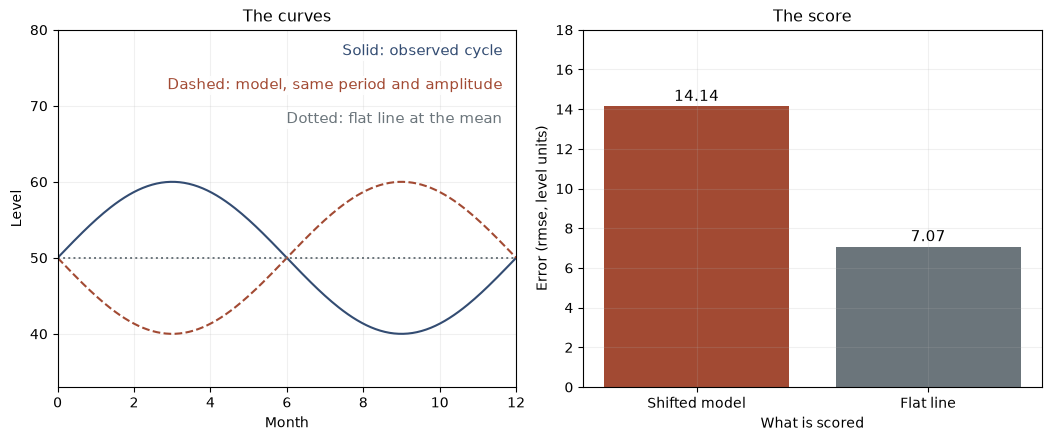

- **Phase shift (cycles):** 0.500
- **Error function:** rmse
- **Shifted model:** 14.14
- **Flat line at the mean:** 7.07

rmse of the shifted model = 2 x 10 x |sin(90.0 deg)| / sqrt(2) = 20.00 / 1.4142 = 14.14. The flat line is 10 / 1.4142 = 7.07. The flat line scores better than a model with the right period and amplitude.

In [11]:
show(cycle_score(shift=0.5, error='rmse'))

**Use the idea.** Score an oscillator on period and amplitude, and report the phase beside them, rather than on distance alone.

**Where the conclusion applies.** Twelve evenly spaced points over one full period, so the rmse formula is exact. With a few points or a partial period the hand formula would not hold.

*Constructed example: a sine cycle defined for this reader to illustrate the chapter's rule on scoring oscillators, scored with the chapter's rmse and shape functions.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(cycle_score, [('shift', [0.0, 0.125, 0.25, 0.5]), ('error', ['rmse', 'shape'])])

- **shift = 0.0, error = rmse**: Phase shift (cycles) 0.000; Error function rmse; Shifted model 0.00; Flat line at the mean 7.07
- **shift = 0.0, error = shape**: Phase shift (cycles) 0.000; Error function shape; Shifted model 0.00; Flat line at the mean 1.00 (correlation undefined, scored 1.0 by rule)
- **shift = 0.125, error = rmse**: Phase shift (cycles) 0.125; Error function rmse; Shifted model 5.41; Flat line at the mean 7.07
- **shift = 0.125, error = shape**: Phase shift (cycles) 0.125; Error function shape; Shifted model 0.29; Flat line at the mean 1.00 (correlation undefined, scored 1.0 by rule)
- **shift = 0.25, error = rmse**: Phase shift (cycles) 0.250; Error function rmse; Shifted model 10.00; Flat line at the mean 7.07
- **shift = 0.25, error = shape**: Phase shift (cycles) 0.250; Error function shape; Shifted model 1.00; Flat line at the mean 1.00 (correlation undefined, scored 1.0 by rule)
- **shift = 0.5, error = rmse**: Phase shift (cycles) 0.500; Error function rmse; Shifted model 14.14; Flat line at the mean 7.07
- **shift = 0.5, error = shape**: Phase shift (cycles) 0.500; Error function shape; Shifted model 2.00; Flat line at the mean 1.00 (correlation undefined, scored 1.0 by rule)

## 2. How many knobs the record allows, and what they cost

*When does the chapter's code refuse a fit, and how fast does a grid get expensive?*

Each free knob is a degree of freedom a wrong structure can spend on looking right, so the chapter's code compares three times the knob count with the points available before it runs anything. A full grid multiplies the runs by the step count for every knob added.

    grid_fit(tank(0.1), [Knob("rate", 0.01, 0.2, steps=9)], [target])

**Symbols and inputs.** A knob is a parameter the fit may move. The rule allows at most one knob per three observations. A grid of 9 steps per knob is searched in 3 passes, so the runs are 9 to the power of the knob count, times 3.

**Predict first.** With a five-point record, does the chapter's code allow a fit of two knobs?

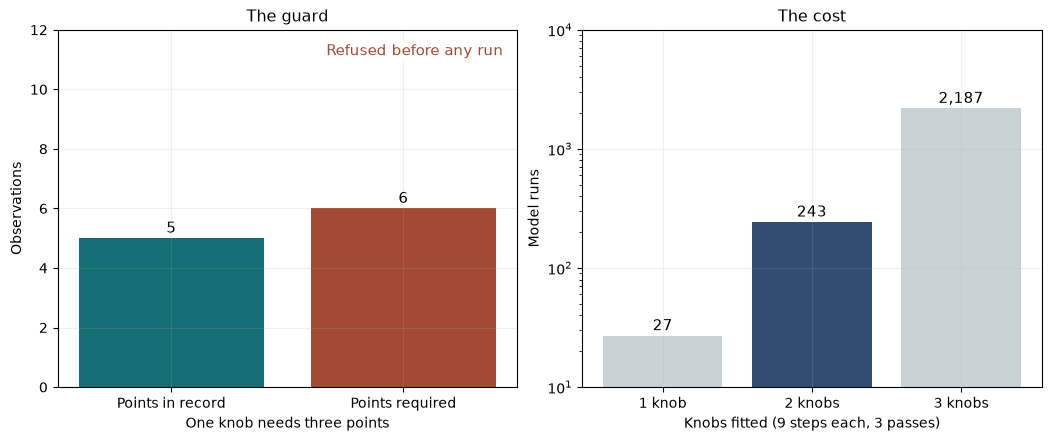

- **Knobs:** 2
- **Observations:** 5
- **Points required:** 6
- **Outcome:** refused
- **Runs at 9 steps and 3 passes:** 243
- **Time at one second a run (minutes):** 4.05

Required points = 3 x 2 = 6, against 5. The fit is refused: 2 knobs against 5 observations, because the rule allows at most one knob per three points. Runs = 9^2 x 3 = 81 x 3 = 243, which at one second a run is 243 / 60 = 4.05 minutes.

In [13]:
show(knob_budget(knobs=2, points=5))

**Use the idea.** Count the evaluations and the seconds per run before choosing the number of knobs for a fit.

**Where the conclusion applies.** One second per model run is a stand-in for a slow model; the tank itself runs in milliseconds. The third knob here moves the starting level, only to count runs, and a real fit would not.

*Constructed example: record lengths defined for this reader from the chapter's tank, with the guard and counts from the chapter's grid_fit function.*

Every setting the interactive reader offers for this demonstration:

In [14]:
sweep(knob_budget, [('knobs', [1, 2, 3]), ('points', [5, 9])])

- **knobs = 1, points = 5**: Knobs 1; Observations 5; Points required 3; Outcome allowed; Runs at 9 steps and 3 passes 27; Time at one second a run (minutes) 0.45
- **knobs = 1, points = 9**: Knobs 1; Observations 9; Points required 3; Outcome allowed; Runs at 9 steps and 3 passes 27; Time at one second a run (minutes) 0.45
- **knobs = 2, points = 5**: Knobs 2; Observations 5; Points required 6; Outcome refused; Runs at 9 steps and 3 passes 243; Time at one second a run (minutes) 4.05
- **knobs = 2, points = 9**: Knobs 2; Observations 9; Points required 6; Outcome allowed; Runs at 9 steps and 3 passes 243; Time at one second a run (minutes) 4.05
- **knobs = 3, points = 5**: Knobs 3; Observations 5; Points required 9; Outcome refused; Runs at 9 steps and 3 passes 2,187; Time at one second a run (minutes) 36.45
- **knobs = 3, points = 9**: Knobs 3; Observations 9; Points required 9; Outcome allowed; Runs at 9 steps and 3 passes 2,187; Time at one second a run (minutes) 36.45

## 3. The tank, fitted by a grid

*What residual does a one-knob grid leave, and how does it depend on steps and passes?*

The fit lands on the nearest grid point, so it misses 0.07 by up to half the finest spacing. More steps or more passes shrink the spacing; a leftover residual is expected and not a flaw.

    grid_fit(tank(0.1), [Knob("rate", 0.01, 0.2, steps=9)], [target])
    rate * level

**Symbols and inputs.** The rate is the fraction of the level leaving each month, searched from 0.01 to 0.2. The record was made with a rate of 0.07. mape is the mean absolute percentage error over the 25 fit months.

**Predict first.** With 9 steps and 2 refinements, is the fitted rate exactly 0.07?

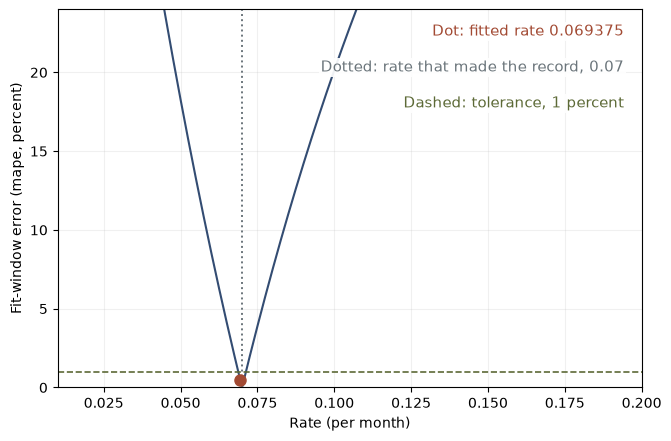

- **Steps per pass:** 9
- **Refinement passes:** 2
- **Model runs:** 27
- **Fitted rate:** 0.069375
- **Fit-window error (mape):** 0.0050
- **Holdout error (mape):** 0.0085
- **Within the 1 percent tolerance:** yes

Runs = 9 x (2 + 1) = 27. Grid spacing: 0.19 / 8 = 0.02375, then 2 x previous / 8 = 0.00594, then 2 x previous / 8 = 0.00148. The fitted rate gives month 1 = 100 + 5 - 0.069375 x 100 = 98.062, against the record's 98.000. Distance from the rate that made the record: 0.069375 - 0.07 = (-0.000625).

In [15]:
show(tank_fit(steps=9, refinements=2))

**Use the idea.** Report the residual and the number of runs with every fitted value, so a reader can repeat the search.

**Where the conclusion applies.** The record is synthetic and noiseless, so a perfect rate exists. A real record has noise, and the best grid point then fits the noise as well.

*Constructed example: the chapter's tank and synthetic record; steps and passes varied for this reader, run with the chapter's grid_fit function.*

Every setting the interactive reader offers for this demonstration:

In [16]:
sweep(tank_fit, [('steps', [3, 5, 9]), ('refinements', [0, 2])])

- **steps = 3, refinements = 0**: Steps per pass 3; Refinement passes 0; Model runs 3; Fitted rate 0.105000; Fit-window error (mape) 0.2284; Holdout error (mape) 0.3365; Within the 1 percent tolerance no
- **steps = 3, refinements = 2**: Steps per pass 3; Refinement passes 2; Model runs 9; Fitted rate 0.105000; Fit-window error (mape) 0.2284; Holdout error (mape) 0.3365; Within the 1 percent tolerance no
- **steps = 5, refinements = 0**: Steps per pass 5; Refinement passes 0; Model runs 5; Fitted rate 0.057500; Fit-window error (mape) 0.1086; Holdout error (mape) 0.1942; Within the 1 percent tolerance no
- **steps = 5, refinements = 2**: Steps per pass 5; Refinement passes 2; Model runs 15; Fitted rate 0.069375; Fit-window error (mape) 0.0050; Holdout error (mape) 0.0085; Within the 1 percent tolerance yes
- **steps = 9, refinements = 0**: Steps per pass 9; Refinement passes 0; Model runs 9; Fitted rate 0.081250; Fit-window error (mape) 0.0842; Holdout error (mape) 0.1351; Within the 1 percent tolerance no
- **steps = 9, refinements = 2**: Steps per pass 9; Refinement passes 2; Model runs 27; Fitted rate 0.069375; Fit-window error (mape) 0.0050; Holdout error (mape) 0.0085; Within the 1 percent tolerance yes

## 4. The wrong knob passes the window and fails the holdout

*If the search may move a measured quantity, does the fit still look good?*

With the rate fixed at the wrong placeholder, a larger inflow can bend the curve through the fit window. It cannot also match the later months, where the mismatch compounds, so the holdout error exceeds its tolerance.

    grid_fit(tank(0.1), [Knob("arrivals", 0.0, 10.0, steps=9)], [target])
    holdout(tank(0.1), fit, [Target("level", hold_window, tolerance=0.02)])

**Symbols and inputs.** The rate knob is the unmeasured quantity. The arrivals knob is the quantity the ledger already reports as 5. The fit window is months 0 to 24 and the holdout is months 25 to 36. Tolerances: 0.01 on the fit, 0.02 on the holdout. Each search uses 9 steps per pass.

**Predict first.** If the search moves arrivals instead of the rate, does the fit pass its own 1 percent tolerance?

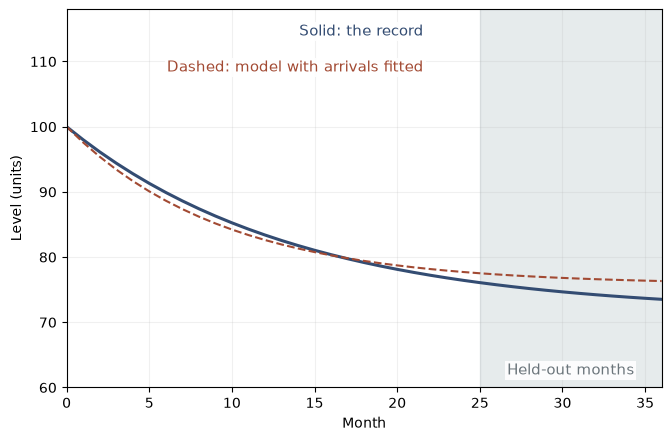

- **Knob moved:** arrivals
- **Fitted arrivals:** 7.5781
- **Fit-window error (mape):** 0.0089
- **Holdout error (mape):** 0.0291
- **Passes the fit tolerance (0.01):** yes
- **Passes the holdout tolerance (0.02):** no

Month 36 in closed form: level = a/r + (100 - a/r) x (1 - r)^36 = 7.578125/0.1000 + (100 - 75.78) x 0.0225 = 76.33, against the record's 73.52: |76.3269 - 73.5242| / 73.5242 = 0.0381. The fit passes its own window and fails the holdout: the wrong knob moved and the holdout caught it.

In [17]:
show(wrong_knob(knob='arrivals', refinements=2))

**Use the idea.** Refuse a knob that could be measured, and always score a withheld window in a separate call.

**Where the conclusion applies.** The holdout catches a fit that worked only where it looked. A wrong structure that happens to track the later months would pass it too.

*Constructed example: the chapter's tank and synthetic record, with fits run by the chapter's grid_fit and holdout functions.*

Every setting the interactive reader offers for this demonstration:

In [18]:
sweep(wrong_knob, [('knob', ['rate', 'arrivals']), ('refinements', [0, 2])])

- **knob = rate, refinements = 0**: Knob moved rate; Fitted rate 0.0813; Fit-window error (mape) 0.0842; Holdout error (mape) 0.1351; Passes the fit tolerance (0.01) no; Passes the holdout tolerance (0.02) no
- **knob = rate, refinements = 2**: Knob moved rate; Fitted rate 0.0694; Fit-window error (mape) 0.0050; Holdout error (mape) 0.0085; Passes the fit tolerance (0.01) yes; Passes the holdout tolerance (0.02) yes
- **knob = arrivals, refinements = 0**: Knob moved arrivals; Fitted arrivals 7.5000; Fit-window error (mape) 0.0106; Holdout error (mape) 0.0191; Passes the fit tolerance (0.01) no; Passes the holdout tolerance (0.02) yes
- **knob = arrivals, refinements = 2**: Knob moved arrivals; Fitted arrivals 7.5781; Fit-window error (mape) 0.0089; Holdout error (mape) 0.0291; Passes the fit tolerance (0.01) yes; Passes the holdout tolerance (0.02) no

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

With a quarter-cycle shift and amplitude 10, what is the rmse?

<details><summary>Answer</summary>

The error amplitude is 2 x 10 x sin(45 deg) = 14.14, and rmse = 14.14 / 1.4142 = 10.00, which is above the flat line's 10 / 1.4142 = 7.07.

</details>

### Exercise 2

A record has 8 points. What is the largest number of knobs the rule allows?

<details><summary>Answer</summary>

3 x knobs <= 8, so knobs <= 2.67, and the largest whole number is 2.

</details>

### Exercise 3

With 5 steps over 0.01 to 0.2, what is the first-pass grid spacing?

<details><summary>Answer</summary>

(0.2 - 0.01) / (5 - 1) = 0.19 / 4 = 0.0475.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/